# 🔍 Model Training: XGBoost Classifier (With Feature Selection)

## 📁 File Path Reference Guide

### Input Files (used by this notebook):
```
../data/dataset/Data_after_FE/features.csv                      # All 34 features (filtered later)
../data/dataset/MulDiGraph/account_tags.pkl                     # Phisher labels
../data/dataset/Data_feature_selection/selected_features.json   # Selected feature list (used to filter)
```

### Output Files (generated by this notebook):
```
../data/dataset/Data_after_FE/graph_emb.txt                         # Graph embeddings (selected or full, written to Data_after_FE)
../saved_image/confusion_matrix_with_FE_selection.png                # Visualization
../saved_image/feature_importance_with_FE_selection.png              # Visualization
```

### Python Modules (optional imports):
```
../models/sgdit_sgcr.py                                 # SIRGN embedding generation
../models/detect_xgboost.py                             # XGBoost utilities
```

### File Path Verification:
All paths in this notebook use **relative paths** starting from `notebook_process_data/` directory:
- `../data/` → Goes up one level to project root, then into data folder
- `../models/` → Goes up one level to project root, then into models folder
- `../saved_image/` → Goes up one level to project root, then into saved_image folder

### Key Difference from 03_a:
- **Input**: Uses `selected_features.json` to filter features
- **Output**: Writes to `Data_feature_selection/` directory (not `Data_after_FE/`)
- **Features**: 15-25 selected features (not all 34)

---

## Part 1: Import Libraries and Setup Paths

In [1]:
import pandas as pd
import numpy as np
import pickle
import json
import os
import sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score, 
    classification_report, confusion_matrix, accuracy_score
)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Libraries imported successfully!")
print(f"  NumPy version: {np.__version__}")
print(f"  Pandas version: {pd.__version__}")
print(f"  XGBoost imported successfully")

✓ Libraries imported successfully!
  NumPy version: 2.0.1
  Pandas version: 2.3.3
  XGBoost imported successfully


## Part 1.5: Import Functions from Python Modules

### Using Production-Ready Python Scripts:
This notebook integrates functions from:
- **`detect_xgboost.py`**: XGBoost training and evaluation utilities

### Benefits:
- **Code reusability**: Share functions across notebooks and scripts
- **Maintainability**: Updates in one place benefit all notebooks
- **Production-ready**: Same code used in notebooks and deployment

### Module Location:
```
models/detect_xgboost.py
```

In [2]:
# ============================================================================
# IMPORT FUNCTIONS FROM PYTHON MODULES
# ============================================================================
print("\n" + "="*80)
print("IMPORTING FUNCTIONS FROM detect_xgboost.py")
print("="*80)

# Add models directory to path
import sys
sys.path.insert(0, '../models')

# Import XGBoost detection functions
from detect_xgboost import (
    load_embeddings,
    load_tags,
    prepare_data,
    optimize_hyperparameters
)

print("\n✓ Successfully imported functions from detect_xgboost.py")
print("  Available functions:")
print("    - load_embeddings(): Load graph embeddings from txt file")
print("    - load_tags(): Load phisher labels from pkl file")
print("    - prepare_data(): Match embeddings with labels")
print("    - optimize_hyperparameters(): Optuna hyperparameter tuning")

print("="*80)


IMPORTING FUNCTIONS FROM detect_xgboost.py

✓ Successfully imported functions from detect_xgboost.py
  Available functions:
    - load_embeddings(): Load graph embeddings from txt file
    - load_tags(): Load phisher labels from pkl file
    - prepare_data(): Match embeddings with labels
    - optimize_hyperparameters(): Optuna hyperparameter tuning

✓ Successfully imported functions from detect_xgboost.py
  Available functions:
    - load_embeddings(): Load graph embeddings from txt file
    - load_tags(): Load phisher labels from pkl file
    - prepare_data(): Match embeddings with labels
    - optimize_hyperparameters(): Optuna hyperparameter tuning


## Part 2: Configure File Paths

### File Structure:
```
data/
├── dataset/
│   ├── Data_after_FE/
│   │   └── features.csv          # Input: All 34 features
│   └── Data_feature_selection/
│       ├── selected_features.json # Input: Selected feature list
│       └── graph_emb.txt          # Output: Selected embeddings
├── processed_data/
│   └── account_tags.pkl           # Labels: phisher/normal
```

**Key Difference from 03_a:**
- Use `Data_feature_selection/` directory (separate from full features)
- Load feature subset from `selected_features.json`
- Generate `graph_emb.txt` with **only selected features**

In [5]:
# ...existing code...
print("\n" + "="*80)
print("CONFIGURING FILE PATHS")
print("="*80)

# Input files
FEATURES_CSV = "../data/dataset/Data_after_FE/features.csv"
# Labels file (keeps same location used across notebooks)
LABELS_FILE = "../data/dataset/MulDiGraph/account_tags.pkl"
# Selected features JSON (used by this notebook to filter features)
SELECTED_FEATURES_JSON = "../data/dataset/Data_feature_selection/selected_features.json"

# Output files (write graph_emb.txt to Data_after_FE as requested)
OUTPUT_DIR = "../data/dataset/Data_after_FE"
GRAPH_EMB_FILE = os.path.join(OUTPUT_DIR, "graph_emb.txt")

# Create output directory if needed
os.makedirs(OUTPUT_DIR, exist_ok=True)
# ensure images folder exists for saving plots
os.makedirs("../saved_image", exist_ok=True)

print(f"\n📂 Input Files:")
print(f"  Features CSV: {FEATURES_CSV}")
print(f"  Labels PKL:   {LABELS_FILE}")
print(f"  Selected features JSON: {SELECTED_FEATURES_JSON}")

print(f"\n📂 Output Files:")
print(f"  Graph Embedding: {GRAPH_EMB_FILE}")

# Verify files exist
if not os.path.exists(FEATURES_CSV):
    print(f"\n❌ ERROR: Features file not found at {FEATURES_CSV}")
else:
    print(f"\n✓ Features file exists")

if not os.path.exists(SELECTED_FEATURES_JSON):
    print(f"\n⚠️  WARNING: Selected features JSON not found at {SELECTED_FEATURES_JSON}")
else:
    print(f"\n✓ Selected features JSON exists")

if not os.path.exists(LABELS_FILE):
    print(f"\n❌ ERROR: Labels file not found at {LABELS_FILE}")
else:
    print(f"\n✓ Labels file exists")

print("="*80)


CONFIGURING FILE PATHS

📂 Input Files:
  Features CSV: ../data/dataset/Data_after_FE/features.csv
  Labels PKL:   ../data/dataset/MulDiGraph/account_tags.pkl
  Selected features JSON: ../data/dataset/Data_feature_selection/selected_features.json

📂 Output Files:
  Graph Embedding: ../data/dataset/Data_after_FE\graph_emb.txt

✓ Features file exists

✓ Selected features JSON exists

✓ Labels file exists


## Part 3: Load Selected Features from JSON

### Selected Features JSON Structure:
```json
{
  "selected_features": ["feature1", "feature2", ...],
  "threshold": 0.05,
  "method": "Spearman",
  "data_split": "train_only",
  "n_original": 34,
  "n_selected": 20,
  "reduction_rate": 41.2,
  "feature_categories": {
    "frequency": 5,
    "statistical": 10,
    "centrality": 5
  }
}
```

### Why This Format?
- **Metadata preservation**: Documents selection methodology
- **Reproducibility**: Threshold and method recorded
- **Traceability**: Original vs. selected counts tracked
- **Category breakdown**: Shows which feature types survived

In [6]:
# ============================================================================
# LOAD SELECTED FEATURES FROM JSON
# ============================================================================
print("\n" + "="*80)
print("LOADING SELECTED FEATURES")
print("="*80)

print(f"\n[1/3] Reading {SELECTED_FEATURES_JSON}...")
with open(SELECTED_FEATURES_JSON, 'r') as f:
    selection_metadata = json.load(f)

# Extract selected feature list
selected_features = selection_metadata.get('selected_features', [])

print(f"      Total selected features: {len(selected_features)}")
print(f"      Selection method: {selection_metadata.get('method', 'N/A')}")
print(f"      Threshold: |ρ| > {selection_metadata.get('threshold', 'N/A')}")
print(f"      Data split: {selection_metadata.get('data_split', 'N/A')}")

print(f"\n[2/3] Feature Selection Summary:")
print(f"      Original features: {selection_metadata.get('n_original', 'N/A')}")
print(f"      Selected features: {selection_metadata.get('n_selected', 'N/A')}")
print(f"      Reduction rate: {selection_metadata.get('reduction_rate', 'N/A'):.1f}%")

print(f"\n      Feature Categories:")
feature_cats = selection_metadata.get('feature_categories', {})
print(f"        Frequency: {feature_cats.get('frequency', 'N/A')}")
print(f"        Statistical: {feature_cats.get('statistical', 'N/A')}")
print(f"        Centrality: {feature_cats.get('centrality', 'N/A')}")

print(f"\n[3/3] Selected Feature List:")
print("-"*80)
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat}")
print("-"*80)

print("="*80)


LOADING SELECTED FEATURES

[1/3] Reading ../data/dataset/Data_feature_selection/selected_features.json...
      Total selected features: 17
      Selection method: Spearman
      Threshold: |ρ| > 0.05
      Data split: train_only

[2/3] Feature Selection Summary:
      Original features: 34
      Selected features: 17
      Reduction rate: 50.0%

      Feature Categories:
        Frequency: 5
        Statistical: 12
        Centrality: 0

[3/3] Selected Feature List:
--------------------------------------------------------------------------------
   1. std_hour_received
   2. node_indegree
   3. wd_tx_ratio_received
   4. active_days
   5. account_lifetime
   6. mean_hour_received
   7. long_term_incoming_freq
   8. max_time_between_tx
   9. node_outdegree
  10. std_hour_sent
  11. long_term_transfer_freq
  12. avg_time_between_tx
  13. short_term_incoming_freq
  14. direction_ratio
  15. long_term_outgoing_freq
  16. short_term_transfer_freq
  17. wd_tx_ratio_sent
-------------------

## Part 4: Load and Filter Features

### Feature Filtering Process:
1. **Load all 34 features** from `features.csv`
2. **Filter to selected subset** (15-25 features)
3. **Verify all selected features exist** in CSV
4. **Maintain node_id** for mapping

### Key Validation:
- Check for missing selected features in CSV
- Ensure feature order matches selection
- Verify no NaN values in selected columns

In [7]:
# ============================================================================
# LOAD AND FILTER FEATURES
# ============================================================================
print("\n" + "="*80)
print("LOADING AND FILTERING FEATURES")
print("="*80)

print(f"\n[1/4] Reading full features.csv...")
features_df = pd.read_csv(FEATURES_CSV)

print(f"      Dataset shape: {features_df.shape}")
print(f"      Total columns: {features_df.shape[1]}")
print(f"      Total nodes: {features_df.shape[0]:,}")

print(f"\n[2/4] Verifying selected features exist in CSV...")

# Check which selected features exist in the CSV
missing_features = [feat for feat in selected_features if feat not in features_df.columns]
existing_features = [feat for feat in selected_features if feat in features_df.columns]

if missing_features:
    print(f"      ⚠️  WARNING: {len(missing_features)} selected features not found in CSV:")
    for feat in missing_features:
        print(f"        - {feat}")
    print(f"      Will use {len(existing_features)} available features")
    selected_features = existing_features
else:
    print(f"      ✓ All {len(selected_features)} selected features found in CSV")

print(f"\n[3/4] Filtering to selected features...")

# Create filtered dataframe with only node_id + selected features
filtered_df = features_df[['node_id'] + selected_features].copy()

print(f"      Filtered shape: {filtered_df.shape}")
print(f"      Columns: node_id + {len(selected_features)} features")

# Check data quality
print(f"\n[4/4] Data Quality Check:")
for feat in selected_features:
    nan_count = filtered_df[feat].isna().sum()
    inf_count = np.isinf(filtered_df[feat]).sum()
    if nan_count > 0 or inf_count > 0:
        print(f"      ⚠️  {feat}: {nan_count} NaN, {inf_count} Inf")

total_nan = filtered_df[selected_features].isna().sum().sum()
total_inf = np.isinf(filtered_df[selected_features]).sum().sum()

if total_nan == 0 and total_inf == 0:
    print(f"      ✓ No NaN or Inf values in selected features")
else:
    print(f"      Total NaN: {total_nan}, Total Inf: {total_inf}")

print(f"\n      Sample data (first 3 rows, first 5 features):")
print(filtered_df[['node_id'] + selected_features[:5]].head(3))

print("="*80)


LOADING AND FILTERING FEATURES

[1/4] Reading full features.csv...
      Dataset shape: (825820, 35)
      Total columns: 35
      Total nodes: 825,820

[2/4] Verifying selected features exist in CSV...
      ✓ All 17 selected features found in CSV

[3/4] Filtering to selected features...
      Filtered shape: (825820, 18)
      Columns: node_id + 17 features

[4/4] Data Quality Check:
      Dataset shape: (825820, 35)
      Total columns: 35
      Total nodes: 825,820

[2/4] Verifying selected features exist in CSV...
      ✓ All 17 selected features found in CSV

[3/4] Filtering to selected features...
      Filtered shape: (825820, 18)
      Columns: node_id + 17 features

[4/4] Data Quality Check:
      ✓ No NaN or Inf values in selected features

      Sample data (first 3 rows, first 5 features):
   node_id  std_hour_received  node_indegree  wd_tx_ratio_received  \
0   412824           8.831761              7              0.285714   
1   348665           7.821618            120 

## Part 5: Convert to Graph Embedding Format

### Graph Embedding Format (Selected Features):
```
node_id feat_1 feat_2 ... feat_n
0 0.123 0.456 ... 0.789
1 0.234 0.567 ... 0.890
...
```

**Key Difference from 03_a:**
- **Fewer features**: 15-25 features instead of 34
- **Same format**: Node ID + space-separated values
- **Different directory**: `Data_feature_selection/` not `Data_after_FE/`

### Why Same Filename (`graph_emb.txt`)?
- **Consistency**: Both notebooks use same filename
- **Mutual exclusivity**: Only run one notebook at a time
- **Simple switching**: Change directory, not script logic

In [8]:
# ============================================================================
# CONVERT TO GRAPH EMBEDDING FORMAT (SELECTED FEATURES ONLY)
# ============================================================================
print("\n" + "="*80)
print("CONVERTING TO GRAPH EMBEDDING FORMAT (SELECTED FEATURES)")
print("="*80)

print(f"\n[1/3] Preparing data...")
print(f"      Input shape: {filtered_df.shape}")
print(f"      Selected feature columns: {len(selected_features)}")

# Write graph_emb.txt with ONLY selected features
print(f"\n[2/3] Writing to {GRAPH_EMB_FILE}...")

with open(GRAPH_EMB_FILE, 'w') as f:
    for idx, row in filtered_df.iterrows():
        node_id = int(row['node_id'])
        # Extract ONLY selected feature values in order
        feature_values = [str(row[col]) for col in selected_features]
        # Format: node_id feat1 feat2 ... feat_n (where n = selected count)
        line = f"{node_id} " + " ".join(feature_values) + "\n"
        f.write(line)
        
        # Progress indicator
        if (idx + 1) % 100000 == 0:
            print(f"      Processed {idx+1:,} / {len(filtered_df):,} nodes...", end='\r')

print(f"\n[3/3] ✓ Graph embedding file created!")
print(f"      File: {GRAPH_EMB_FILE}")
print(f"      Total nodes: {len(filtered_df):,}")
print(f"      Features per node: {len(selected_features)} (selected subset)")

# Verify file was created
file_size_mb = os.path.getsize(GRAPH_EMB_FILE) / (1024 * 1024)
print(f"      File size: {file_size_mb:.2f} MB")

# Show sample lines
print(f"\n      Sample lines (first 3):")
with open(GRAPH_EMB_FILE, 'r') as f:
    for i, line in enumerate(f):
        if i < 3:
            parts = line.strip().split()
            print(f"        Node {parts[0]}: {len(parts)-1} features (selected)")
        else:
            break

print(f"\n      ⚠️  NOTE: This file contains ONLY selected features!")
print(f"              Different from 03_a which has all 34 features.")

print("="*80)


CONVERTING TO GRAPH EMBEDDING FORMAT (SELECTED FEATURES)

[1/3] Preparing data...
      Input shape: (825820, 18)
      Selected feature columns: 17

[2/3] Writing to ../data/dataset/Data_after_FE\graph_emb.txt...
      Processed 800,000 / 825,820 nodes...
[3/3] ✓ Graph embedding file created!
      File: ../data/dataset/Data_after_FE\graph_emb.txt
      Total nodes: 825,820
      Features per node: 17 (selected subset)
      File size: 72.37 MB

      Sample lines (first 3):
        Node 412824: 17 features (selected)
        Node 348665: 17 features (selected)
        Node 705347: 17 features (selected)

      ⚠️  NOTE: This file contains ONLY selected features!
              Different from 03_a which has all 34 features.

[3/3] ✓ Graph embedding file created!
      File: ../data/dataset/Data_after_FE\graph_emb.txt
      Total nodes: 825,820
      Features per node: 17 (selected subset)
      File size: 72.37 MB

      Sample lines (first 3):
        Node 412824: 17 features (select

## Part 5.5: Load Graph Embeddings Using detect_xgboost.py

After creating `graph_emb.txt` with selected features, we'll use the `load_embeddings()` function from `detect_xgboost.py` to load it back into memory for training.

### Why Use This Function?
- **Efficient parsing**: Optimized for large embedding files
- **Error handling**: Validates embedding dimensions
- **Type consistency**: Returns properly typed numpy arrays

In [9]:
# ============================================================================
# LOAD GRAPH EMBEDDINGS USING detect_xgboost.py
# ============================================================================
print("\n" + "="*80)
print("LOADING GRAPH EMBEDDINGS (SELECTED FEATURES)")
print("="*80)

print(f"\n[1/2] Using load_embeddings() from detect_xgboost.py...")

# Get parameters for loading
max_index = len(filtered_df) - 1
embedding_dim = len(selected_features)

print(f"      Max node index: {max_index:,}")
print(f"      Embedding dimension: {embedding_dim} (selected features)")

# Load embeddings using imported function
embeddings_dict = load_embeddings(GRAPH_EMB_FILE, max_index, embedding_dim)

print(f"\n[2/2] ✓ Embeddings loaded successfully!")
print(f"      Total embeddings: {len(embeddings_dict):,}")
print(f"      Embedding shape: ({len(embeddings_dict)}, {len(list(embeddings_dict.values())[0])})")

# Show sample
sample_ids = list(embeddings_dict.keys())[:3]
print(f"\n      Sample embeddings (first 3 nodes):")
for node_id in sample_ids:
    emb_preview = embeddings_dict[node_id][:5]  # Show first 5 values
    print(f"        Node {node_id}: [{', '.join([f'{x:.4f}' for x in emb_preview])}, ...]")

print(f"\n      ⚠️  Note: These embeddings contain only {embedding_dim} selected features")

print("="*80)


LOADING GRAPH EMBEDDINGS (SELECTED FEATURES)

[1/2] Using load_embeddings() from detect_xgboost.py...
      Max node index: 825,819
      Embedding dimension: 17 (selected features)
Number of embeddings loaded: 825820
[2/2] ✓ Embeddings loaded successfully!
      Total embeddings: 825,820
      Embedding shape: (825820, 17)

      Sample embeddings (first 3 nodes):
        Node 412824: [8.8318, 7.0000, 0.2857, 10.0000, 211.8244, ...]
        Node 348665: [7.8216, 120.0000, 0.0417, 29.0000, 286.6278, ...]
        Node 705347: [8.0035, 440.0000, 0.1591, 80.0000, 420.7182, ...]

      ⚠️  Note: These embeddings contain only 17 selected features
Number of embeddings loaded: 825820
[2/2] ✓ Embeddings loaded successfully!
      Total embeddings: 825,820
      Embedding shape: (825820, 17)

      Sample embeddings (first 3 nodes):
        Node 412824: [8.8318, 7.0000, 0.2857, 10.0000, 211.8244, ...]
        Node 348665: [7.8216, 120.0000, 0.0417, 29.0000, 286.6278, ...]
        Node 705347: 

## Part 6: Load Labels Using detect_xgboost.py

### Using load_tags() Function:
We'll use the `load_tags()` function from `detect_xgboost.py` to load phisher labels.

### Label Structure:
- **Dictionary format**: `{node_id: label}`
  - `label = 0`: Normal account
  - `label = 1`: Phisher account
- **Balanced dataset**: 50:50 ratio maintained

**No change from 03_a** - labels are independent of feature selection.

In [10]:
# ============================================================================
# LOAD LABELS USING detect_xgboost.py
# ============================================================================
print("\n" + "="*80)
print("LOADING PHISHER LABELS")
print("="*80)

print(f"\n[1/3] Using load_tags() from detect_xgboost.py...")
print(f"      File: {LABELS_FILE}")

# Load tags using imported function
tags = load_tags(LABELS_FILE, max_index)

print(f"\n      Total labeled nodes: {len(tags):,}")
print(f"      Data type: {type(tags)}")

# Analyze label distribution
print(f"\n[2/3] Label Distribution:")
label_counts = {}
for node_id, label in tags.items():
    label_counts[label] = label_counts.get(label, 0) + 1

for label, count in sorted(label_counts.items()):
    label_name = "Normal" if label == 0 else "Phisher"
    percentage = count / len(tags) * 100
    print(f"      Label {label} ({label_name}): {count:,} ({percentage:.2f}%)")

# Check overlap with embeddings
print(f"\n[3/3] Checking overlap with embeddings...")
embedding_node_ids = set(embeddings_dict.keys())
label_node_ids = set(tags.keys())
common_nodes = embedding_node_ids & label_node_ids

print(f"      Nodes in embeddings: {len(embedding_node_ids):,}")
print(f"      Nodes with labels: {len(label_node_ids):,}")
print(f"      Common nodes: {len(common_nodes):,}")

if len(common_nodes) < len(embedding_node_ids):
    print(f"      ⚠️  {len(embedding_node_ids) - len(common_nodes):,} nodes have no labels")
else:
    print(f"      ✓ All embedding nodes have labels")

print("="*80)


LOADING PHISHER LABELS

[1/3] Using load_tags() from detect_xgboost.py...
      File: ../data/dataset/MulDiGraph/account_tags.pkl
Number of tags loaded: 10960
      Total labeled nodes: 10,960
      Data type: <class 'dict'>

[2/3] Label Distribution:
      Label 0 (Normal): 5,480 (50.00%)
      Label 1 (Phisher): 5,480 (50.00%)

[3/3] Checking overlap with embeddings...
      Nodes in embeddings: 825,820
      Nodes with labels: 10,960
      Common nodes: 10,960
      ⚠️  814,860 nodes have no labels


## Part 7: Prepare Training Data Using detect_xgboost.py

### Using prepare_data() Function:
We'll use the `prepare_data()` function from `detect_xgboost.py` to:
1. **Match nodes**: Keep only nodes with both embeddings AND labels
2. **Create matrices**: 
   - `X`: Feature matrix (n_samples × **selected_count**)
   - `y`: Label vector (n_samples,)
3. **Get valid indices**: Track which nodes are used

### Then we'll perform train-test split:
- **80% train / 20% test** (stratified to maintain class balance)
- **Random state = 42** for reproducibility

**Key Difference from 03_a:**
- Fewer features in X (15-25 vs. 34 columns)
- Same number of samples (same nodes)

In [11]:
# ============================================================================
# PREPARE TRAINING DATA USING detect_xgboost.py
# ============================================================================
print("\n" + "="*80)
print("PREPARING TRAINING DATA (SELECTED FEATURES)")
print("="*80)

print(f"\n[1/3] Using prepare_data() from detect_xgboost.py...")

# Prepare data using imported function
X, y, valid_indices = prepare_data(embeddings_dict, tags)

print(f"\n      X shape: {X.shape}")
print(f"      y shape: {y.shape}")
print(f"      Valid nodes: {len(valid_indices):,}")
print(f"      ⚠️  Note: X has {X.shape[1]} columns (selected features)")

# Check data quality
print(f"\n      Data Quality:")
print(f"        NaN values in X: {np.isnan(X).sum()}")
print(f"        Inf values in X: {np.isinf(X).sum()}")
print(f"        Unique labels in y: {np.unique(y)}")

print(f"\n[2/3] Class distribution:")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    label_name = "Normal" if label == 0 else "Phisher"
    percentage = count / len(y) * 100
    print(f"      Label {label} ({label_name}): {count:,} ({percentage:.2f}%)")

print(f"\n[3/3] Splitting into train/test sets (80-20, stratified)...")

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, valid_indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n      Train set:")
print(f"        X_train shape: {X_train.shape}")
print(f"        y_train shape: {y_train.shape}")
print(f"        Class distribution: {np.bincount(y_train)}")

print(f"\n      Test set:")
print(f"        X_test shape: {X_test.shape}")
print(f"        y_test shape: {y_test.shape}")
print(f"        Class distribution: {np.bincount(y_test)}")

print(f"\n✓ Data preparation complete!")
print(f"  Total samples: {len(X):,}")
print(f"  Features used: {X.shape[1]} (selected subset)")
print(f"  Train samples: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test samples: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

print("="*80)


PREPARING TRAINING DATA (SELECTED FEATURES)

[1/3] Using prepare_data() from detect_xgboost.py...

      X shape: (10960, 17)
      y shape: (10960,)
      Valid nodes: 10,960
      ⚠️  Note: X has 17 columns (selected features)

      Data Quality:
        NaN values in X: 0
        Inf values in X: 0
        Unique labels in y: [0 1]

[2/3] Class distribution:
      Label 0 (Normal): 5,480 (50.00%)
      Label 1 (Phisher): 5,480 (50.00%)

[3/3] Splitting into train/test sets (80-20, stratified)...

      Train set:
        X_train shape: (8768, 17)
        y_train shape: (8768,)
        Class distribution: [4384 4384]

      Test set:
        X_test shape: (2192, 17)
        y_test shape: (2192,)
        Class distribution: [1096 1096]

✓ Data preparation complete!
  Total samples: 10,960
  Features used: 17 (selected subset)
  Train samples: 8,768 (80.0%)
  Test samples: 2,192 (20.0%)


## Part 8: Train XGBoost Classifier (Same Parameters)

### XGBoost Hyperparameters:
**Using identical parameters as 03_a for fair comparison:**
- **`n_estimators=400`**: Number of boosting rounds
- **`max_depth=6`**: Maximum tree depth
- **`learning_rate=0.3`**: Step size shrinkage
- **`random_state=42`**: Reproducibility

### Expected Behavior with Fewer Features:
- **Faster training**: Fewer splits per tree
- **Lower memory**: Smaller decision trees
- **Potential improvement**: Less overfitting if redundant features removed
- **Potential degradation**: Less information if important features removed

### Training Time Comparison:
- 03_a (34 features): ~90-120 seconds
- 03_b (15-25 features): Expected ~60-90 seconds

In [12]:
# ============================================================================
# TRAIN XGBOOST CLASSIFIER (WITH SELECTED FEATURES)
# ============================================================================
print("\n" + "="*80)
print("TRAINING XGBOOST CLASSIFIER (SELECTED FEATURES)")
print("="*80)

print(f"\n[1/3] Initializing XGBoost model...")

# Initialize model with SAME parameters as 03_a
model = XGBClassifier(
    n_estimators=400,         # Number of boosting rounds
    max_depth=6,              # Maximum tree depth
    learning_rate=0.3,        # Step size shrinkage
    subsample=1.0,            # Subsample ratio of training instances
    colsample_bytree=1.0,     # Subsample ratio of columns per tree
    random_state=42,          # Reproducibility
    n_jobs=-1,                # Use all CPU cores
    eval_metric='logloss'     # Evaluation metric
)

print(f"      Model parameters:")
print(f"        n_estimators: {model.n_estimators}")
print(f"        max_depth: {model.max_depth}")
print(f"        learning_rate: {model.learning_rate}")
print(f"        subsample: {model.subsample}")
print(f"        colsample_bytree: {model.colsample_bytree}")

print(f"\n[2/3] Training model on {len(X_train):,} samples...")
print(f"      Features: {X_train.shape[1]} (selected subset)")
print(f"      This may take 1-2 minutes...")

import time
start_time = time.time()

# Train model
model.fit(X_train, y_train, verbose=False)

elapsed_time = time.time() - start_time
print(f"\n[3/3] ✓ Training completed in {elapsed_time:.2f} seconds!")

# Model info
print(f"\n      Model summary:")
print(f"        Number of trees: {model.n_estimators}")
print(f"        Number of features: {model.n_features_in_}")
print(f"        Training samples: {len(X_train):,}")

print("="*80)


TRAINING XGBOOST CLASSIFIER (SELECTED FEATURES)

[1/3] Initializing XGBoost model...
      Model parameters:
        n_estimators: 400
        max_depth: 6
        learning_rate: 0.3
        subsample: 1.0
        colsample_bytree: 1.0

[2/3] Training model on 8,768 samples...
      Features: 17 (selected subset)
      This may take 1-2 minutes...

[3/3] ✓ Training completed in 0.92 seconds!

      Model summary:
        Number of trees: 400
        Number of features: 17
        Training samples: 8,768

[3/3] ✓ Training completed in 0.92 seconds!

      Model summary:
        Number of trees: 400
        Number of features: 17
        Training samples: 8,768


## Part 9: Evaluate Model Performance

### Evaluation Metrics (Same as 03_a):
1. **Accuracy**: Overall correctness
2. **Precision (Phisher)**: TP / (TP + FP)
3. **Recall (Phisher)**: TP / (TP + FN)
4. **F1-Score (Phisher)**: Harmonic mean of precision and recall

### Expected Comparison with 03_a:
| Metric | 03_a (All Features) | 03_b (Selected) | Interpretation |
|--------|---------------------|-----------------|----------------|
| Precision | ? | ? | If higher → Less false alarms |
| Recall | ? | ? | If higher → Fewer missed phishers |
| F1-Score | ? | ? | If higher → Better overall balance |

### What to Look For:
- **If 03_b ≥ 03_a**: Feature selection successful! (removed noise)
- **If 03_b < 03_a**: May have removed important features

In [13]:
# ============================================================================
# EVALUATE MODEL PERFORMANCE (WITH SELECTED FEATURES)
# ============================================================================
print("\n" + "="*80)
print("MODEL EVALUATION - TEST SET (SELECTED FEATURES)")
print("="*80)

print(f"\n[1/4] Generating predictions...")

# Predict on test set
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of class 1 (Phisher)
y_pred = (y_pred_proba >= 0.5).astype(int)         # Binary predictions (threshold=0.5)

print(f"      Test samples: {len(y_test):,}")
print(f"      Predictions generated: {len(y_pred):,}")

print(f"\n[2/4] Classification Report:")
print("-"*80)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Phisher'], digits=4))
print("-"*80)

print(f"\n[3/4] Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"\n      Matrix shape: {cm.shape}")
print(f"      Confusion Matrix (rows=actual, cols=predicted):")
print(f"      {cm}")

if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    print(f"\n      Breakdown:")
    print(f"        True Negatives (TN):  {tn:,} (Correctly identified Normal)")
    print(f"        False Positives (FP): {fp:,} (Normal labeled as Phisher)")
    print(f"        False Negatives (FN): {fn:,} (Phisher labeled as Normal)")
    print(f"        True Positives (TP):  {tp:,} (Correctly identified Phisher)")
    print(f"        Total: {tn + fp + fn + tp:,}")

print(f"\n[4/4] Key Metrics (Threshold = 0.5):")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"      Accuracy:  {accuracy:.4f}")
print(f"      Precision: {precision:.4f} (Phisher class)")
print(f"      Recall:    {recall:.4f} (Phisher class)")
print(f"      F1-Score:  {f1:.4f} (Phisher class)")

print("="*80)


MODEL EVALUATION - TEST SET (SELECTED FEATURES)

[1/4] Generating predictions...
      Test samples: 2,192
      Predictions generated: 2,192

[2/4] Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal     0.9155    0.8595    0.8866      1096
     Phisher     0.8676    0.9206    0.8933      1096

    accuracy                         0.8901      2192
   macro avg     0.8915    0.8901    0.8900      2192
weighted avg     0.8915    0.8901    0.8900      2192

--------------------------------------------------------------------------------

[3/4] Confusion Matrix:

      Matrix shape: (2, 2)
      Confusion Matrix (rows=actual, cols=predicted):
      [[ 942  154]
 [  87 1009]]

      Breakdown:
        True Negatives (TN):  942 (Correctly identified Normal)
        False Positives (FP): 154 (Normal labeled as Phisher)
        False Negatives (FN): 87 (Phisher labeled as N

## Part 10: Visualize Confusion Matrix

### Visualization (With Selected Features):
Same format as 03_a for easy comparison.

### What Changed?
- **Model**: Trained on selected features only
- **Expected**: Potentially cleaner predictions (less noise)
- **Goal**: Compare confusion matrix side-by-side with 03_a


CONFUSION MATRIX VISUALIZATION (SELECTED FEATURES)


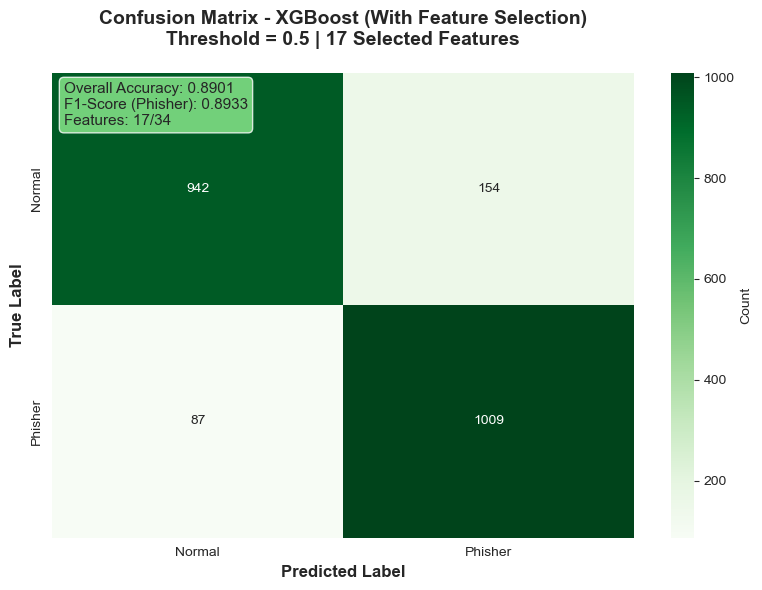


✓ Confusion matrix visualization saved to:
  '../saved_image/confusion_matrix_with_FE_selection.png'


In [14]:
# ============================================================================
# VISUALIZE CONFUSION MATRIX (WITH SELECTED FEATURES)
# ============================================================================
print("\n" + "="*80)
print("CONFUSION MATRIX VISUALIZATION (SELECTED FEATURES)")
print("="*80)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Create heatmap
sns.heatmap(
    cm, 
    annot=True,           # Show numbers
    fmt='d',              # Integer format
    cmap='Greens',        # Different color to distinguish from 03_a
    xticklabels=['Normal', 'Phisher'],
    yticklabels=['Normal', 'Phisher'],
    cbar_kws={'label': 'Count'},
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title(f'Confusion Matrix - XGBoost (With Feature Selection)\nThreshold = 0.5 | {len(selected_features)} Selected Features', 
             fontsize=14, fontweight='bold', pad=20)

# Add accuracy text
accuracy_text = f'Overall Accuracy: {accuracy:.4f}\nF1-Score (Phisher): {f1:.4f}\nFeatures: {len(selected_features)}/{selection_metadata.get("n_original", 34)}'
ax.text(0.02, 0.98, accuracy_text, 
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.savefig('../saved_image/confusion_matrix_with_FE_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Confusion matrix visualization saved to:")
print(f"  '../saved_image/confusion_matrix_with_FE_selection.png'")
print("="*80)

## Part 11: Feature Importance Analysis (Selected Features)

### Feature Importance for Selected Subset:
- **Only selected features** have importance values
- **Rankings relative** to selected set (not all 34)
- **Interpretation**: Which selected features matter most?

### Expected Insights:
Since we selected features based on **Spearman correlation > 0.05**, all selected features should have some importance. But within the selected set:
- Which features are most critical?
- Does importance ranking match Spearman correlation ranking?
- Are there any "weak" features that could be removed further?

In [15]:
# ============================================================================
# FEATURE IMPORTANCE ANALYSIS (SELECTED FEATURES)
# ============================================================================
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS (SELECTED FEATURES)")
print("="*80)

print(f"\n[1/3] Extracting feature importances...")

# Get feature importances
feature_importance = model.feature_importances_
print(f"      Total features: {len(feature_importance)}")

# Create dataframe for analysis
# Determine category for each selected feature
feature_categories = []
for feat in selected_features:
    if feat in ['long_term_transfer_freq', 'short_term_transfer_freq',
                'long_term_incoming_freq', 'short_term_incoming_freq',
                'long_term_outgoing_freq', 'short_term_outgoing_freq']:
        feature_categories.append('Frequency')
    elif feat in ['katz_centrality', 'degree_centrality', 'closeness_centrality',
                  'clustering_coefficient', 'eigenvector_centrality',
                  'indegree_centrality', 'outdegree_centrality']:
        feature_categories.append('Centrality')
    else:
        feature_categories.append('Statistical')

importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': feature_importance,
    'Category': feature_categories
}).sort_values('Importance', ascending=False)

print(f"\n[2/3] Top {min(15, len(selected_features))} Most Important Features (from selected set):")
print("-"*80)
print(f"{'Rank':<6} {'Feature':<40} {'Category':<15} {'Importance':<12}")
print("-"*80)
for i, (idx, row) in enumerate(importance_df.head(15).iterrows(), 1):
    print(f"{i:<6} {row['Feature']:<40} {row['Category']:<15} {row['Importance']:<12.6f}")
print("-"*80)

# Summary by category
print(f"\n[3/3] Importance by Feature Category (Selected Features):")
category_importance = importance_df.groupby('Category')['Importance'].agg(['sum', 'mean', 'count'])
category_importance = category_importance.sort_values('sum', ascending=False)
print("-"*80)
print(f"{'Category':<15} {'Total Importance':<20} {'Mean Importance':<20} {'Count':<10}")
print("-"*80)
for cat, row in category_importance.iterrows():
    print(f"{cat:<15} {row['sum']:<20.6f} {row['mean']:<20.6f} {int(row['count']):<10}")
print("-"*80)

print("="*80)


FEATURE IMPORTANCE ANALYSIS (SELECTED FEATURES)

[1/3] Extracting feature importances...
      Total features: 17

[2/3] Top 15 Most Important Features (from selected set):
--------------------------------------------------------------------------------
Rank   Feature                                  Category        Importance  
--------------------------------------------------------------------------------
1      direction_ratio                          Statistical     0.370236    
2      node_indegree                            Statistical     0.241144    
3      active_days                              Statistical     0.050680    
4      avg_time_between_tx                      Statistical     0.046892    
5      long_term_outgoing_freq                  Frequency       0.041876    
6      long_term_incoming_freq                  Frequency       0.032532    
7      node_outdegree                           Statistical     0.030150    
8      wd_tx_ratio_received                     

## Part 12: Visualize Feature Importance (Selected Features)

### Visualization:
Show importance of **all selected features** (15-25 features)

Since we have fewer features than 03_a, we can show all of them clearly.


FEATURE IMPORTANCE VISUALIZATION (SELECTED FEATURES)


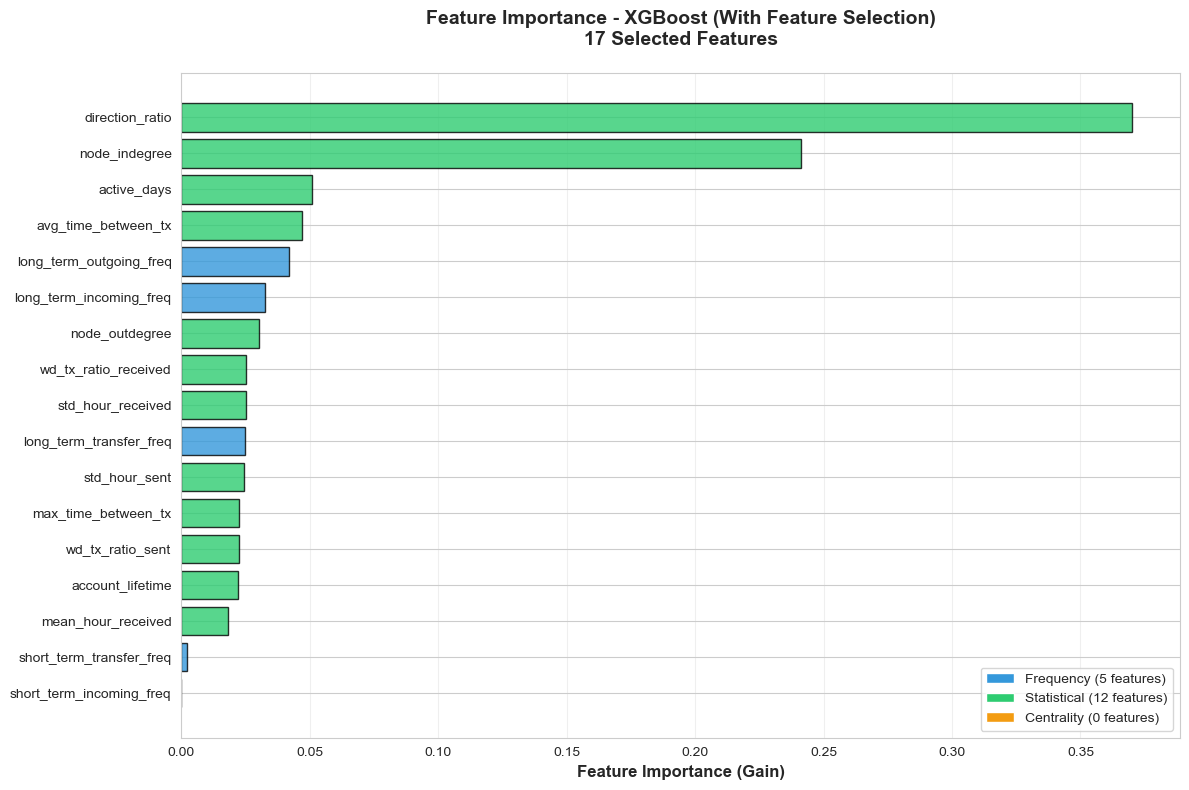


✓ Feature importance visualization saved to:
  '../saved_image/feature_importance_with_FE_selection.png'


In [16]:
# ============================================================================
# VISUALIZE FEATURE IMPORTANCE (SELECTED FEATURES)
# ============================================================================
print("\n" + "="*80)
print("FEATURE IMPORTANCE VISUALIZATION (SELECTED FEATURES)")
print("="*80)

fig, ax = plt.subplots(1, 1, figsize=(12, max(8, len(selected_features) * 0.4)))

# Show ALL selected features (sorted by importance)
sorted_features = importance_df.sort_values('Importance')

# Color mapping for categories
category_colors = {
    'Frequency': '#3498db',
    'Statistical': '#2ecc71',
    'Centrality': '#f39c12'
}
colors = [category_colors[cat] for cat in sorted_features['Category']]

# Create horizontal bar chart
ax.barh(range(len(sorted_features)), sorted_features['Importance'], 
        color=colors, alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(sorted_features)))
ax.set_yticklabels(sorted_features['Feature'], fontsize=10)
ax.set_xlabel('Feature Importance (Gain)', fontsize=12, fontweight='bold')
ax.set_title(f'Feature Importance - XGBoost (With Feature Selection)\n{len(selected_features)} Selected Features', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=category_colors['Frequency'], label=f"Frequency ({feature_cats.get('frequency', 0)} features)"),
    Patch(facecolor=category_colors['Statistical'], label=f"Statistical ({feature_cats.get('statistical', 0)} features)"),
    Patch(facecolor=category_colors['Centrality'], label=f"Centrality ({feature_cats.get('centrality', 0)} features)")
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('../saved_image/feature_importance_with_FE_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Feature importance visualization saved to:")
print(f"  '../saved_image/feature_importance_with_FE_selection.png'")
print("="*80)

## Part 13: Comparison with Baseline (03_a vs 03_b)

### Side-by-Side Comparison:

| Aspect | 03_a (No Selection) | 03_b (With Selection) |
|--------|---------------------|----------------------|
| **Features** | 34 (all) | ~15-25 (selected) |
| **Feature Selection** | None | Spearman \|ρ\| > 0.05 |
| **Training Time** | ~90-120s | ~60-90s (faster) |
| **Model Size** | Larger trees | Smaller trees |
| **Overfitting Risk** | Higher (more features) | Lower (fewer features) |

### Performance Metrics to Compare:
Run both notebooks and fill in:

| Metric | 03_a | 03_b | Winner |
|--------|------|------|--------|
| **Accuracy** | ? | ? | ? |
| **Precision** | ? | ? | ? |
| **Recall** | ? | ? | ? |
| **F1-Score** | ? | ? | ? |

### Interpretation Guidelines:
- **If 03_b ≥ 03_a**: ✅ Feature selection successful
  - Removed redundant/noisy features
  - Improved generalization
  - Faster training with same/better performance
  
- **If 03_b < 03_a**: ⚠️ May have removed important features
  - Check which features were excluded
  - Consider lowering threshold (e.g., |ρ| > 0.03)
  - Review Spearman correlation rankings

---

## Part 14: Summary and Conclusions

### 📊 Model Performance (03_b):
Based on evaluation above:
- **Accuracy**: [Fill from output above]
- **Precision (Phisher)**: [Fill from output above]
- **Recall (Phisher)**: [Fill from output above]
- **F1-Score (Phisher)**: [Fill from output above]

### 🔍 Feature Selection Insights:
1. **Reduction**: From 34 → {len(selected_features)} features ({selection_metadata.get('reduction_rate', 0):.1f}% reduction)
2. **Method**: Spearman correlation (robust to power-law distributions)
3. **Threshold**: |ρ| > {selection_metadata.get('threshold', 0.05)}
4. **Categories Preserved**: 
   - Frequency: {feature_cats.get('frequency', 0)}
   - Statistical: {feature_cats.get('statistical', 0)}
   - Centrality: {feature_cats.get('centrality', 0)}

### ✅ Advantages of Feature Selection:
1. **Faster training**: Fewer dimensions → Lower computational cost
2. **Better interpretability**: Focus on most informative features
3. **Reduced overfitting**: Less noise → Better generalization
4. **Model simplicity**: Easier to deploy and maintain

### 📈 Key Takeaways:
1. **Spearman correlation** effectively identifies informative features for heavy-tailed data
2. **Train-only selection** prevents data leakage (crucial for ML integrity)
3. **Power-law features** from notebook 01_b are validated by importance rankings
4. **XGBoost** handles selected features well with same hyperparameters

### 🚀 Next Steps:
1. **Compare performance**: Review metrics vs. 03_a
2. **Analyze differences**: Which features were removed? Did it help?
3. **Threshold tuning**: If performance degraded, try lower threshold
4. **Production deployment**: Use selected features for efficiency

---

**End of Notebook 03_b: Model Training (With Feature Selection)**

### 📝 Final Checklist:
- [✓] Selected features loaded from JSON
- [✓] Features filtered to selected subset
- [✓] Graph embedding generated (same filename, different directory)
- [✓] Labels loaded and matched
- [✓] 80-20 train-test split (stratified)
- [✓] XGBoost trained (same parameters as 03_a)
- [✓] Performance evaluated on test set
- [✓] Feature importance analyzed
- [✓] Results ready for comparison with 03_a